# Random Forest and XGBoost

Fits traditional ML models (proposal.txt Sections 10.4-10.5) on the engineered feature set from `05_feature_engineering.ipynb` (`data/processed/features.csv`), using the same chronological 70/15/15 split as the other model notebooks. Economic passthrough columns (`gdp`, `electricity_price`, `per_capita_energy_use`) are excluded from the feature set, consistent with `05_feature_engineering.ipynb`'s decision to keep them out of the primary model features for now. Includes feature-importance and SHAP explainability (Section 20).

In [ ]:
import sys
from pathlib import Path

import yaml

# Works both in the local repo and on Kaggle. Locally, config.yaml is read
# from disk. On Kaggle there is no repo checkout -- only whatever cells you
# paste -- so the config is built inline instead, pointed at the attached
# dataset under /kaggle/input.
IS_KAGGLE = Path("/kaggle/input/datasets/uom230425m").exists()

if IS_KAGGLE:
    import os

    available = os.listdir("/kaggle/input/datasets/uom230425m/time-series-project")
    print("Kaggle input datasets found:", available)
    if len(available) != 1:
        raise RuntimeError(
            "Expected exactly one dataset under /kaggle/input -- set "
            "KAGGLE_DATASET_DIR manually to the one containing "
            "load_forecasting_dataset_corrected.csv."
        )
    KAGGLE_DATASET_DIR = Path("/kaggle/input") / available[0]

    REPO_ROOT = Path("/kaggle/working")
    config = {
        "data": {
            "raw_path": str(KAGGLE_DATASET_DIR),
            "processed_path": "/kaggle/working/data/processed",
            "processed_file": "/kaggle/working/data/processed/demand_clean.csv",
            "features_file": "/kaggle/working/data/processed/features.csv",
            "timestamp_col": "timestamp",
            "target_col": "demand",
            "frequency": "h",
        },
        "split": {"train_ratio": 0.70, "val_ratio": 0.15, "test_ratio": 0.15},
        "models": {
            "xgboost_path": "/kaggle/working/models/xgboost_model.pkl",
            "xgboost_feature_columns": "/kaggle/working/models/xgboost_feature_columns.json",
        },
    }
else:
    def find_repo_root(start: Path) -> Path:
        for parent in [start, *start.parents]:
            if (parent / "config.yaml").exists():
                return parent
        raise FileNotFoundError("config.yaml not found in any parent directory")

    REPO_ROOT = find_repo_root(Path.cwd())
    sys.path.insert(0, str(REPO_ROOT))

    with open(REPO_ROOT / "config.yaml") as f:
        config = yaml.safe_load(f)

config

Kaggle input datasets found: ['datasets']


{'data': {'raw_path': '/kaggle/input/datasets',
  'processed_path': '/kaggle/working/data/processed',
  'processed_file': '/kaggle/working/data/processed/demand_clean.csv',
  'features_file': '/kaggle/working/data/processed/features.csv',
  'timestamp_col': 'timestamp',
  'target_col': 'demand',
  'frequency': 'h'},
 'split': {'train_ratio': 0.7, 'val_ratio': 0.15, 'test_ratio': 0.15},
 'models': {'xgboost_path': '/kaggle/working/models/xgboost_model.pkl',
  'xgboost_feature_columns': '/kaggle/working/models/xgboost_feature_columns.json'}}

In [2]:
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# On Kaggle, src/ isn't on disk (only pasted cells are) -- these are
# identical inline copies of src/data/load_data.py, src/models/machine_learning.py,
# src/evaluation/metrics.py, and src/visualization/plots.py.
# Keep them in sync with src/ if that logic ever changes.
if IS_KAGGLE:
    from sklearn.ensemble import RandomForestRegressor
    from xgboost import XGBRegressor

    def load_raw_data(path, timestamp_col="timestamp"):
        df = pd.read_csv(path, parse_dates=[timestamp_col])
        return df.sort_values(timestamp_col).reset_index(drop=True)

    def set_timestamp_index(df, timestamp_col="timestamp"):
        df = df.set_index(timestamp_col)
        return df.sort_index()

    def chronological_split(df, train_ratio, val_ratio):
        n = len(df)
        train_end = int(n * train_ratio)
        val_end = int(n * (train_ratio + val_ratio))
        return df.iloc[:train_end], df.iloc[train_end:val_end], df.iloc[val_end:]

    def fit_random_forest(X_train, y_train, **params):
        model = RandomForestRegressor(random_state=42, **params)
        return model.fit(X_train, y_train)

    def fit_xgboost(X_train, y_train, **params):
        model = XGBRegressor(random_state=42, **params)
        return model.fit(X_train, y_train)

    def mae(y_true, y_pred):
        return np.mean(np.abs(y_true - y_pred))

    def rmse(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred) ** 2))

    def mape(y_true, y_pred):
        return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    def smape(y_true, y_pred):
        denom = (np.abs(y_true) + np.abs(y_pred)) / 2
        return np.mean(np.abs(y_true - y_pred) / denom) * 100

    def mase(y_true, y_pred, y_train, season_length=1):
        naive_error = np.mean(np.abs(y_train[season_length:] - y_train[:-season_length]))
        return np.mean(np.abs(y_true - y_pred)) / naive_error

    def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted"):
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(y_true.index, y_true.values, label="Actual")
        ax.plot(y_pred.index, y_pred.values, label="Predicted", alpha=0.8)
        ax.set_title(title)
        ax.legend()
        return fig
else:
    from src.data.load_data import chronological_split, load_raw_data, set_timestamp_index
    from src.evaluation.metrics import mae, mape, mase, rmse, smape
    from src.models.machine_learning import fit_random_forest, fit_xgboost
    from src.visualization.plots import plot_actual_vs_predicted

FEATURES_PATH = REPO_ROOT / config["data"]["features_file"]
TIMESTAMP_COL = config["data"]["timestamp_col"]
TARGET_COL = config["data"]["target_col"]
TRAIN_RATIO = config["split"]["train_ratio"]
VAL_RATIO = config["split"]["val_ratio"]

## Load engineered features and chronological split

In [3]:
df = load_raw_data(FEATURES_PATH, TIMESTAMP_COL)
df = set_timestamp_index(df, TIMESTAMP_COL)

train_df, val_df, test_df = chronological_split(df, TRAIN_RATIO, VAL_RATIO)

EXCLUDE_COLS = [TARGET_COL, "gdp", "electricity_price", "per_capita_energy_use"]
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE_COLS]

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]

print(f"Train: {len(train_df)} rows, {len(FEATURE_COLS)} features")
print(f"Test:  {len(test_df)} rows")

Train: 33112 rows, 33 features
Test:  7096 rows


## Fit Random Forest and XGBoost

Hyperparameters below are reasonable defaults from the possibilities listed in proposal.txt Section 15, not the result of an exhaustive search.

In [4]:
RF_PARAMS = dict(n_estimators=200, max_depth=12, min_samples_leaf=5, n_jobs=-1)
XGB_PARAMS = dict(
    n_estimators=300, learning_rate=0.05, max_depth=6, min_child_weight=5,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1,
)

models = {}
timings = {}

for name, fit_fn, params in [
    ("Random Forest", fit_random_forest, RF_PARAMS),
    ("XGBoost", fit_xgboost, XGB_PARAMS),
]:
    start = time.perf_counter()
    model = fit_fn(X_train, y_train, **params)
    train_time = time.perf_counter() - start
    models[name] = model
    timings[name] = {"training_time_seconds": train_time}
    print(f"{name}: trained in {train_time:.1f}s")

Random Forest: trained in 56.4s
XGBoost: trained in 1.9s


## Evaluate on the test set

In [5]:
y_train_arr = y_train.to_numpy()

results = []
predictions = {}
for name, model in models.items():
    start = time.perf_counter()
    y_pred = pd.Series(model.predict(X_test), index=y_test.index)
    pred_time = time.perf_counter() - start
    predictions[name] = y_pred

    results.append({
        "model": name,
        "mae": mae(y_test, y_pred),
        "rmse": rmse(y_test, y_pred),
        "mape": mape(y_test, y_pred),
        "smape": smape(y_test, y_pred),
        "mase": mase(y_test.to_numpy(), y_pred.to_numpy(), y_train_arr, season_length=24),
        "training_time_seconds": timings[name]["training_time_seconds"],
        "prediction_time_seconds": pred_time,
    })

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
results_df

,model,mae,rmse,mape,smape,mase,training_time_seconds,prediction_time_seconds
0,Random Forest,0.033567,1.043493,0.002606,0.002563,0.000296,56.372310,0.112364
1,XGBoost,1.076223,2.592483,0.073060,0.073014,0.009491,1.934198,0.023955


## Feature importance (XGBoost)

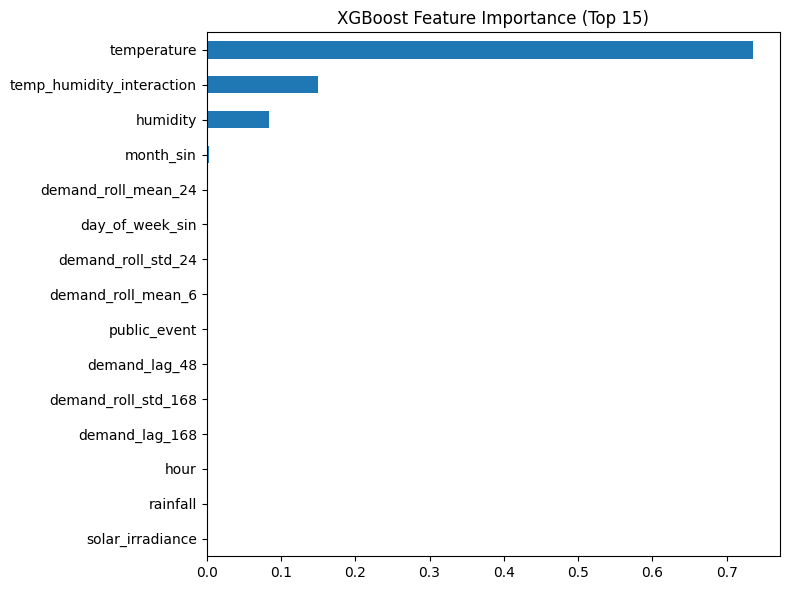

In [6]:
importances = pd.Series(models["XGBoost"].feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

FIGURES_DIR = REPO_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).sort_values().plot.barh(ax=ax)
ax.set_title("XGBoost Feature Importance (Top 15)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "xgboost_feature_importance.png", dpi=150, bbox_inches="tight")

## SHAP feature attribution

Uses a sample of the test set for speed -- proposal.txt Section 20 notes SHAP should be used "if computationally practical".

In [7]:
import shap

sample = X_test.sample(min(1000, len(X_test)), random_state=42)
explainer = shap.TreeExplainer(models["XGBoost"])
shap_values = explainer.shap_values(sample)

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, sample, show=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "xgboost_shap_summary.png", dpi=150, bbox_inches="tight")
plt.close()

## Visualize the best model's forecast

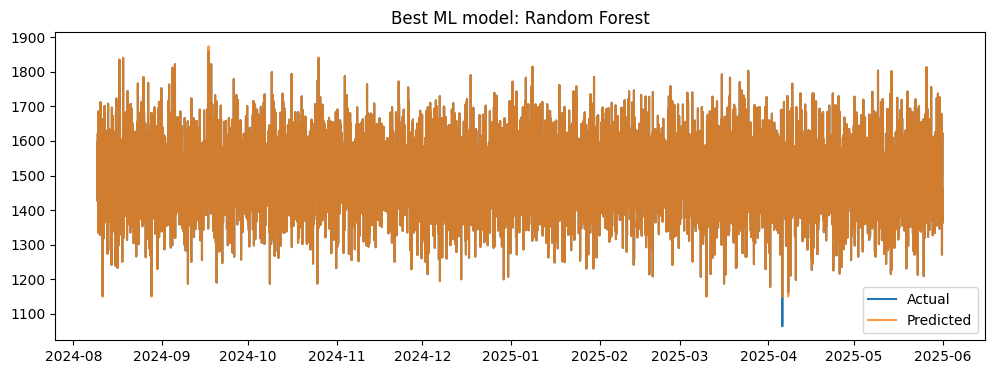

In [8]:
best_model_name = results_df.iloc[0]["model"]
best_predictions = predictions[best_model_name]

fig = plot_actual_vs_predicted(y_test, best_predictions, title=f"Best ML model: {best_model_name}")
fig.savefig(FIGURES_DIR / "ml_best_forecast.png", dpi=150, bbox_inches="tight")

## Save predictions and results

In [9]:
predictions_df = pd.concat([
    pd.DataFrame({
        "timestamp": y_test.index,
        "actual": y_test.values,
        "predicted": pred.values,
        "model": name,
    })
    for name, pred in predictions.items()
], ignore_index=True)

PREDICTIONS_PATH = REPO_ROOT / "reports" / "ml_predictions.csv"
predictions_df.to_csv(PREDICTIONS_PATH, index=False)

RESULTS_PATH = REPO_ROOT / "reports" / "ml_metrics.csv"
results_df.to_csv(RESULTS_PATH, index=False)

print(f"Saved {len(predictions_df)} prediction rows to {PREDICTIONS_PATH}")
print(f"Saved ML results to {RESULTS_PATH}")

Saved 14192 prediction rows to /kaggle/working/reports/ml_predictions.csv
Saved ML results to /kaggle/working/reports/ml_metrics.csv


## Save the XGBoost model artifact

In [10]:
MODELS_DIR = REPO_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(models["XGBoost"], REPO_ROOT / config["models"]["xgboost_path"])
with open(REPO_ROOT / config["models"]["xgboost_feature_columns"], "w") as f:
    json.dump(FEATURE_COLS, f, indent=1)

print(f"Saved XGBoost model and {len(FEATURE_COLS)} feature columns to {MODELS_DIR}")

Saved XGBoost model and 33 feature columns to /kaggle/working/models
